In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.simulation.result import SimulationResult
from ksb.planning.solvers.scurve import SCurveSolver
from ksb.planning.solvers.quintic import QuinticSolver
from ksb.motion.trajectories import (
    CompositeTrajectory,
    ConstantJerkTrajectory,
    LinearTrajectory,
    PolynomialTrajectory,
    P, V, A,
)

import yaml
from pathlib import Path
with open(Path('..') / 'configs' / 'default.yaml') as f:
    cfg = yaml.safe_load(f)

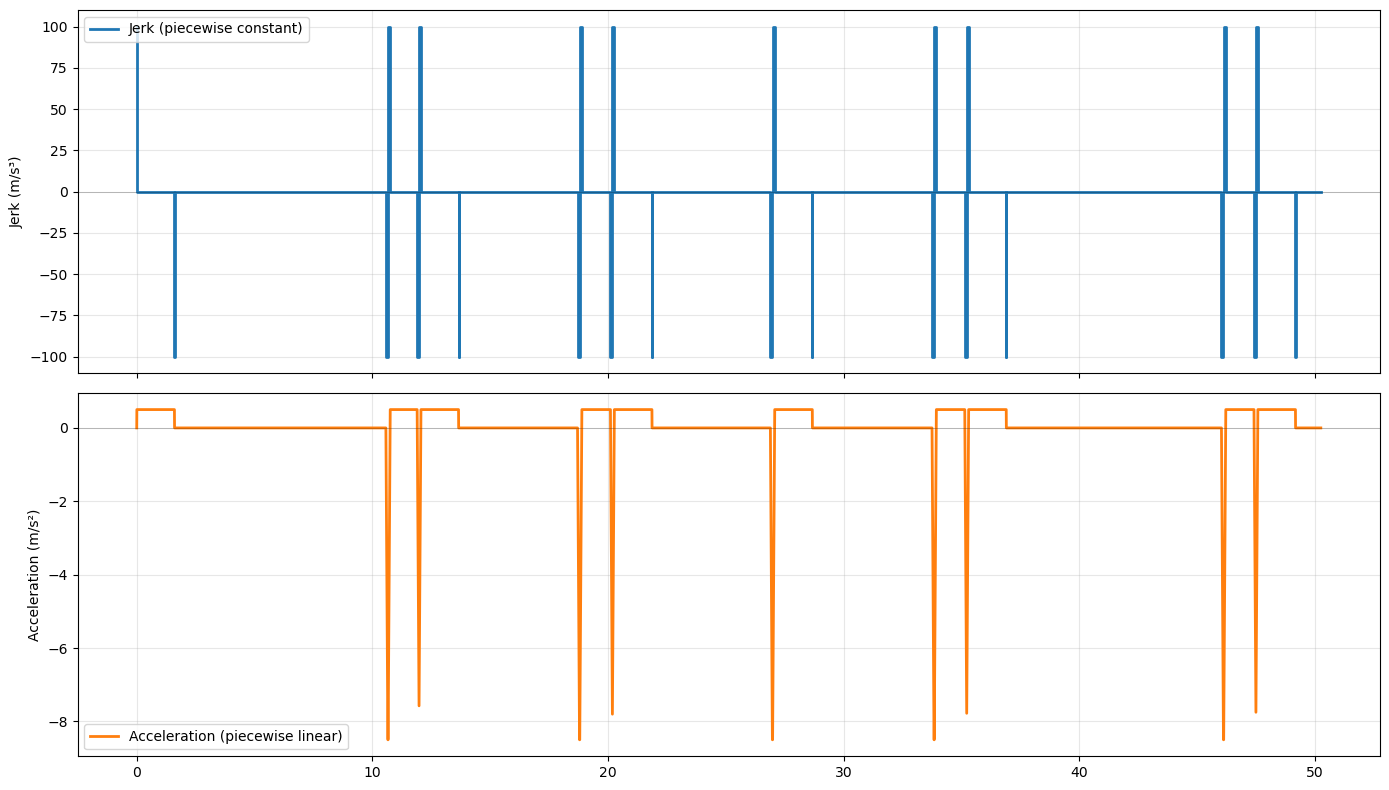

Total timeline duration: 50.26 s
Number of segments: 124
Final velocity: 1.691 m/s
Nominal upstream velocity: 1.200 m/s


In [2]:
# ── Run simulation and display ────────────────────────────────────────────────
sim = KSBSimulation(cfg=cfg)
result = sim.run(seed=42)

# Extract timeline: list of (t_start, jerk, duration) tuples
timeline = sim._u_control._timeline

# Build piecewise constant jerk plot
t_jerk = []
j_vals = []

for t_start, jerk, duration in timeline:
    t_end = t_start + duration
    # Step plot: constant jerk value during [t_start, t_end]
    t_jerk.extend([t_start, t_end])
    j_vals.extend([jerk, jerk])

# Build piecewise linear acceleration and piecewise quadratic velocity
t_accel = []
a_vals = []
t_vel = []
v_vals = []

a_current = 0.0
v_current = sim.vu

for t_start, jerk, duration in timeline:
    t_end = t_start + duration
    
    # Sample acceleration at segment start and end (linear between them)
    t_accel.extend([t_start, t_end])
    a_vals.extend([a_current, a_current + jerk * duration])
    
    # For velocity, sample multiple points over the segment (quadratic curve)
    # v(t) = v_current + a_current * (t - t_start) + 0.5 * jerk * (t - t_start)^2
    n_samples = max(10, int(duration * 100))  # More samples for longer segments
    dt_sample = duration / n_samples
    for i in range(n_samples + 1):
        t_rel = i * dt_sample
        v_sample = v_current + a_current * t_rel + 0.5 * jerk * t_rel**2
        t_vel.append(t_start + t_rel)
        v_vals.append(v_sample)
    
    # Update state at end of segment
    a_current += jerk * duration
    v_current += a_current * duration + 0.5 * jerk * duration**2

# Create figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot jerk (piecewise constant - step plot)
axes[0].step(t_jerk, j_vals, where='post', linewidth=2, color='tab:blue', label='Jerk (piecewise constant)')
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
axes[0].set_ylabel('Jerk (m/s³)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot acceleration (piecewise linear - line plot)
axes[1].plot(t_accel, a_vals, linewidth=2, color='tab:orange', label='Acceleration (piecewise linear)')
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
axes[1].set_ylabel('Acceleration (m/s²)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total timeline duration: {timeline[-1][0] + timeline[-1][2]:.2f} s")
print(f"Number of segments: {len(timeline)}")
print(f"Final velocity: {v_current:.3f} m/s")
print(f"Nominal upstream velocity: {sim.vu:.3f} m/s")